In [ ]:
# Install and Load Required Packages
if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")
BiocManager::install(c("DESeq2", "limma", "WGCNA", "impute", "preprocessCore", "GO.db", "AnnotationDbi"))

library(DESeq2)
library(limma)
library(WGCNA)

# Load Data and Metadata
metadata <- read.csv("/content/metadata.csv", row.names = 1, header = TRUE)
data <- read.csv("/content/updated_count_matrix (1).csv", row.names = 1, header = TRUE)

# Ensure Column Names in Count Matrix Match Sample IDs in Metadata
stopifnot(all(colnames(data) %in% rownames(metadata)))  # Will stop if not TRUE

# Filter Genes Based on Counts > 15 in at least 25% of Samples
data <- data[rowSums(data > 15) > round(0.25 * ncol(data)), ]
cat("Number of genes retained after filtering:", nrow(data), "\n")

# Prepare Metadata
metadata$batch <- as.factor(metadata$batch)
metadata$category <- as.factor(metadata$category)

# Set Reference Level for "category"
metadata$category <- relevel(metadata$category, ref = "Normal")

# Create DESeq2 Object and Perform Normalization
dds <- DESeqDataSetFromMatrix(countData = data, colData = metadata, design = ~ batch + category)
dds <- DESeq(dds)

# Apply Variance-Stabilizing Transformation (VST)
vsd <- vst(dds, blind = FALSE)

# Batch Correction Using limma's removeBatchEffect
vsd_counts <- assay(vsd)  # Extract VST-transformed counts
design_matrix <- model.matrix(~ category, data = metadata)  # Design matrix to preserve category effect
assay(vsd) <- removeBatchEffect(vsd_counts, batch = metadata$batch, design = design_matrix)

# Extract Final Processed Data for WGCNA
data <- assay(vsd)  # Final normalized, batch-corrected data
data <- t(data)  # Transpose: Rows = Samples, Columns = Genes (required for WGCNA)

# Check the Processed Data
cat("Processed data dimensions (samples x genes):", dim(data), "\n")
head(data)


'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'DESeq2' 'limma' 'WGCNA' 'impute'
  'preprocessCore' 'GO.db' 'AnnotationDbi'”
Old packages: 'bit64', 'bslib', 'cli', 'curl', 'evaluate', 'foreign', 'httr2',
  'Matrix', 'nlme', 'openssl', 'pillar', 'pkgbuild', 'processx', 'purrr', 'R6',
  'Rcpp', 'rlang', 'rpart', 'sessioninfo', 'systemfonts', 'testthat',
  'textshaping', 'xfun', 'zip'

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked f

Number of genes retained after filtering: 25750 


  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning 

Processed data dimensions (samples x genes): 279 25750 


,DDX11L1,WASH7P,MIR6859-1,MIR1302-2,FAM138A,OR4F5,WASH9P,LOC729737,DDX11L17,LOC102723897,⋯,ND4,TRNH,TRNS2,TRNL2,ND5,ND6,TRNE,CYTB,TRNT,TRNP
GSM1401790,5.011149,8.288473,2.742142,2.988506,5.401372,4.575276,5.553469,5.857518,5.276028,8.300490,⋯,14.20050,5.526815,4.646182,5.699547,14.29289,12.90194,9.165383,13.92546,7.984762,7.354136
GSM1401791,4.284658,8.976230,3.354127,2.988506,5.405070,4.575276,5.719839,7.320135,4.233413,8.754686,⋯,13.36409,5.268184,4.195871,5.354815,13.53759,12.18766,7.815707,12.83695,7.711641,7.690355
GSM1401792,4.548791,8.630409,3.463724,2.988506,5.559461,5.015806,5.737158,7.638449,4.986826,8.531677,⋯,13.96588,5.533249,4.717749,5.704579,14.23174,12.76379,8.642377,13.56393,8.353193,8.334323
GSM1401793,5.518375,8.371871,3.401340,2.988506,6.066826,4.575276,6.615815,6.899403,6.083414,8.355099,⋯,14.14722,6.318738,5.626959,6.564674,14.57427,13.15985,8.947631,14.03856,8.397477,7.722823
GSM1401794,4.728489,9.133591,3.489175,2.988506,5.733531,5.369976,5.842740,7.344913,4.771743,8.930453,⋯,14.49786,5.604007,4.894205,5.908443,14.76172,13.32822,8.793365,13.92120,8.519045,8.383725
GSM1401795,4.464790,8.686625,3.770304,3.385940,5.499139,4.575276,5.843280,7.721102,4.535706,8.685656,⋯,12.81322,5.996892,5.729790,6.407532,12.82301,11.63431,7.999425,11.97007,6.726095,7.189741


[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 12 14 16 18 20
[26] 22 24 26 28 30 32 34 36 38 40 42 44 46 48 50

pickSoftThreshold: will use block size 1737.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 1737 of 25750


Warning message:
“executing %dopar% sequentially: no parallel backend registered”


   ..working on genes 1738 through 3474 of 25750
   ..working on genes 3475 through 5211 of 25750
   ..working on genes 5212 through 6948 of 25750
   ..working on genes 6949 through 8685 of 25750
   ..working on genes 8686 through 10422 of 25750
   ..working on genes 10423 through 12159 of 25750
   ..working on genes 12160 through 13896 of 25750
   ..working on genes 13897 through 15633 of 25750
   ..working on genes 15634 through 17370 of 25750
   ..working on genes 17371 through 19107 of 25750
   ..working on genes 19108 through 20844 of 25750
   ..working on genes 20845 through 22581 of 25750
   ..working on genes 22582 through 24318 of 25750
   ..working on genes 24319 through 25750 of 25750
   Power SFT.R.sq  slope truncated.R.sq  mean.k. median.k.  max.k.
1      1   0.4330  7.070          0.947 1.32e+04  1.32e+04 14600.0
2      2   0.0496 -0.909          0.796 7.25e+03  7.11e+03  9340.0
3      3   0.5930 -2.600          0.872 4.22e+03  4.04e+03  6590.0
4      4   0.7120 -2.510   

[1] "Power"          "SFT.R.sq"       "slope"          "truncated.R.sq"
[5] "mean.k."        "median.k."      "max.k."


Attaching package: ‘gridExtra’


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:BiocGenerics’:

    combine




 Calculating module eigengenes block-wise from all genes
   Flagging genes and samples with too many missing values...
    ..step 1
 ..Working on block 1 .
    TOM calculation: adjacency..
    ..will not use multithreading.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    ..normalization..
    ..done.
   ..saving TOM for block 1 into file TOM-block.1.RData
 ....clustering..
 ....detecting modules..
 ....calculating module eigengenes..
 ....checking kME in modules..
     ..removing 140 genes from module 1 because their KME is too low.
     ..removing 70 genes from module 2 because their KME is too low.
     ..removing 11 genes from module 3 because their KME is too low.
     ..removing 46 genes from module 4 because their KME is too low.
     ..removing 2 genes from module 6 because their KME is too low.
     ..removing 6 genes from module 7 because their KME is too low.
     ..removing 2 genes from module 8 because their 

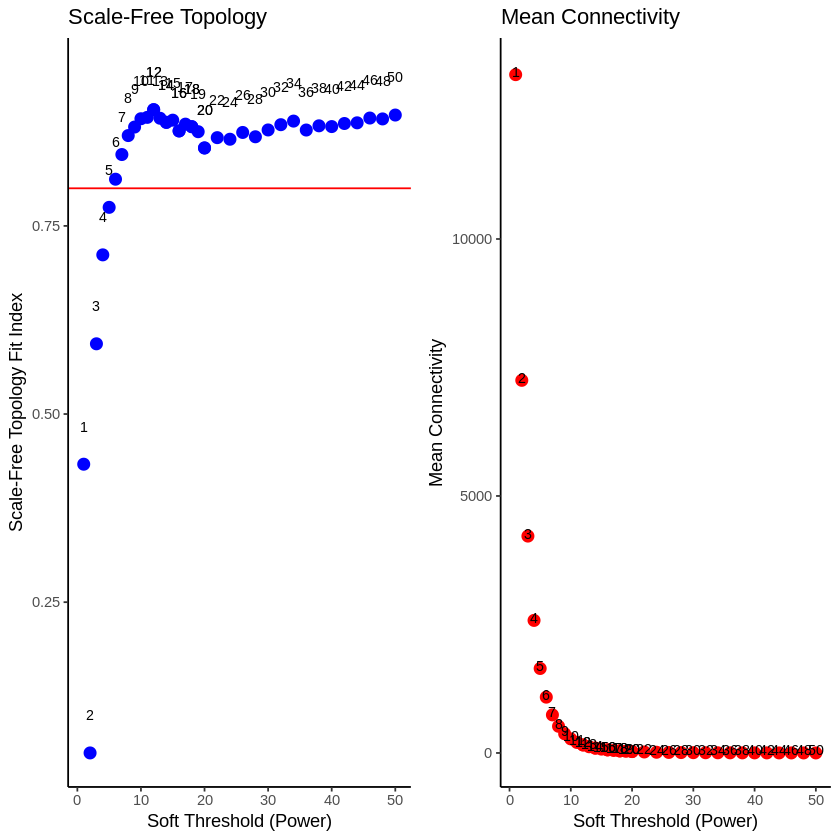

In [ ]:
# Choose a set of soft-threshholding powers
power <- c(c(1:20), seq(from = 12, to = 50, by = 2))
power

## RunpickSoftThreshold
sft <- pickSoftThreshold(
	data,
	powerVector = power,
	networkType = "signed",
	verbose = 5
)


sft.data <- sft$fitIndices
names(sft.data)

# Ensure necessary libraries are loaded
library(ggplot2)
library(gridExtra)  # For arranging multiple plots

a1 <- ggplot(sft.data, aes(x = Power, y = SFT.R.sq, label = Power)) +
  geom_point(size = 3, color = 'blue') +
  geom_text(nudge_y = 0.05, size = 3) +
  geom_hline(yintercept = 0.8, color = 'red') +
  labs(x = 'Soft Threshold (Power)',
       y = 'Scale-Free Topology Fit Index',
       title = 'Scale-Free Topology') +
  theme_classic()

a2 <- ggplot(sft.data, aes(x = Power, y = mean.k., label = Power)) +
  geom_point(size = 3, color = 'red') +
  geom_text(nudge_y = 50, size = 3) +
  labs(x = 'Soft Threshold (Power)',
       y = 'Mean Connectivity',
       title = 'Mean Connectivity') +
  theme_classic()

ggsave("scale_free_topology.png", grid.arrange(a1, a2, ncol = 2), width = 10, height = 5)

write.csv(sft.data, "soft_thresholding_results.csv")


# Temporarily override the default correlation function for WGCNA
# temp_cor <- cor
# cor <- WGCNA::cor


# Ensure Data is Properly Transposed (Samples x Genes)
#cat("Data dimensions (samples x genes):", dim(data), "\n")

# Enable Parallel Processing to Speed Up Computation
#enableWGCNAThreads()

# Re-run blockwiseModules for Module Detection
softPower <- 6  # Use the previously selected soft-thresholding power

net <- blockwiseModules(
  data,
  power = softPower,                # Soft-thresholding power
  maxBlockSize = 26000,             # Adjust based on the number of genes
  TOMType = "signed",               # Use a signed network
  minModuleSize = 30,               # Minimum number of genes per module
  reassignThreshold = 0,            # Threshold for reassigning genes
  mergeCutHeight = 0.25,            # Threshold for merging similar modules
  numericLabels = TRUE,             # Use numeric module labels
  randomSeed = 1234,               # For reproducibility
  saveTOMs = TRUE,                  # Save the TOM for future use
  saveTOMFileBase = "TOM",          # File prefix for TOM
  verbose = 3                       # Display detailed progress
)


In [ ]:
load("TOM-block.1.RData")  # e.g. "TOM-block.1.RData"
# If it loads as a "dist" class (commonly used for large matrices),
# convert carefully to a matrix ONLY if you really need all ~26k x 26k:
TOM <- as.matrix(TOM)
summary(diag(TOM))
# If near 0 → you have the dissimilarity (1 - actualTOM).
TOM <- 1 - TOM
# Now diag(TOM) should be near 1.
summary(diag(TOM))
# If near 0 → you have the dissimilarity (1 - actualTOM).

      ModuleLabel  ModuleColor
1             ME3        brown
4             ME5        green
5             ME1    turquoise
7             ME0         grey
16            ME2         blue
25            ME4       yellow
35           ME17       grey60
44            ME8         pink
54            ME7        black
65           ME10       purple
138           ME9      magenta
163           ME6          red
175          ME11  greenyellow
342          ME15 midnightblue
394          ME14         cyan
982          ME13       salmon
1462         ME16    lightcyan
3208         ME12          tan
7290         ME18   lightgreen
12439        ME19  lightyellow
Number of modules detected: 20 
Modules detected (colors): brown green turquoise grey blue yellow grey60 pink black purple magenta red greenyellow midnightblue cyan salmon lightcyan tan lightgreen lightyellow 


pdf 
  2

,Gene,Module
,<chr>,<chr>
1,DDX11L1,brown
2,WASH7P,brown
3,MIR6859-1,brown
4,MIR1302-2,green
5,FAM138A,turquoise
6,OR4F5,turquoise


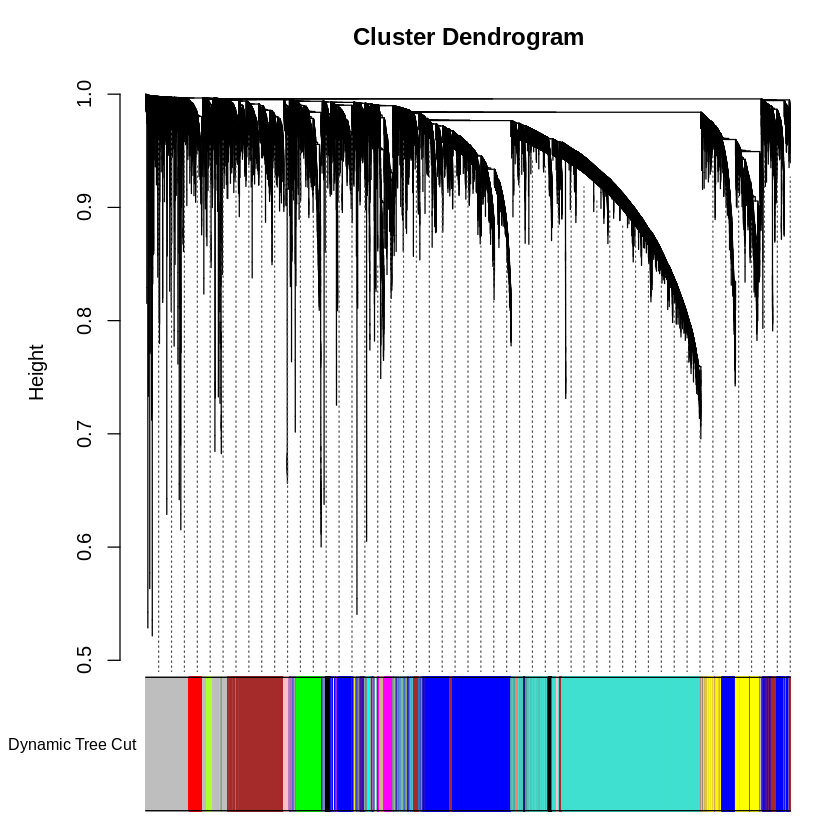

In [ ]:
# Extract Results
moduleLabels <- net$colors  # Module labels for each gene
moduleColors <- labels2colors(moduleLabels)  # Convert numeric labels to colors
MEs <- net$MEs  # Module eigengenes (summary expression profiles of modules)
# TOM <- 1 - net$dissTOM  # Topological overlap matrix (for network construction)

# Create a mapping between module labels and module colors, using the ME names from the eigengenes.
mapping_df <- unique(data.frame(
  ModuleLabel = paste0("ME", moduleLabels),  # add the "ME" prefix
  ModuleColor = moduleColors
))
print(mapping_df)
# Save mapping_df mapping as CSV
write.csv(mapping_df, "module_label_color_mapping.csv", row.names = FALSE)

# Save Results
save(moduleLabels, moduleColors, MEs, TOM, file = "WGCNA_results_full.RData")

# Summarize Modules
moduleSummary <- table(moduleColors)
write.csv(moduleSummary, "module_summary.csv")  # Save summary as CSV

cat("Number of modules detected:", length(unique(moduleColors)), "\n")
cat("Modules detected (colors):", unique(moduleColors), "\n")

# Plot and Save Module Dendrogram
plotDendroAndColors(
  net$dendrograms[[1]],               # Dendrogram for block 1
  moduleColors[net$blockGenes[[1]]],  # Module colors for block 1
  "Dynamic Tree Cut",                 # Title
  dendroLabels = FALSE,               # No labels on dendrogram
  hang = 0.03,                        # How much to hang the branches
  addGuide = TRUE,                    # Add guide lines for visualization
  guideHang = 0.05                    # Height of guide lines
)
ggsave(
  "module_dendrogram_fixed.png",
  width = 50,  # Adjust to appropriate size
  height = 30, # Adjust to appropriate size
  dpi = 300,   # Specify DPI for high resolution
  limitsize = FALSE
)

# High-Resolution Heatmap of Module Eigengenes
MEcor <- cor(MEs)
png("module_eigengene_heatmap_high_res.png", width = 3600, height = 2400, res = 300)
heatmap(
  as.matrix(cor(MEs)),         # Correlation matrix of module eigengenes
  symm = TRUE,                 # Symmetric heatmap
  main = "Module Eigengene Correlation Heatmap"
)
dev.off()

# Gene-to-Module Assignments
geneModuleAssignments <- data.frame(Gene = colnames(data), Module = moduleColors)
write.csv(geneModuleAssignments, "gene_module_assignments.csv")

# View the first few rows of assignments
head(geneModuleAssignments)


Trait Matrix (Dummy Variables):
           categoryER+ categoryHER2+ categoryTNBC
GSM1401790           0             0            0
GSM1401791           0             0            0
GSM1401792           0             0            0
GSM1401793           0             0            0
GSM1401794           0             0            0
GSM1401795           0             0            0
Module-Trait Results Saved as 'module_trait_summary.csv'


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



png 
  3

Heatmap saved as 'module_trait_heatmap.png'.


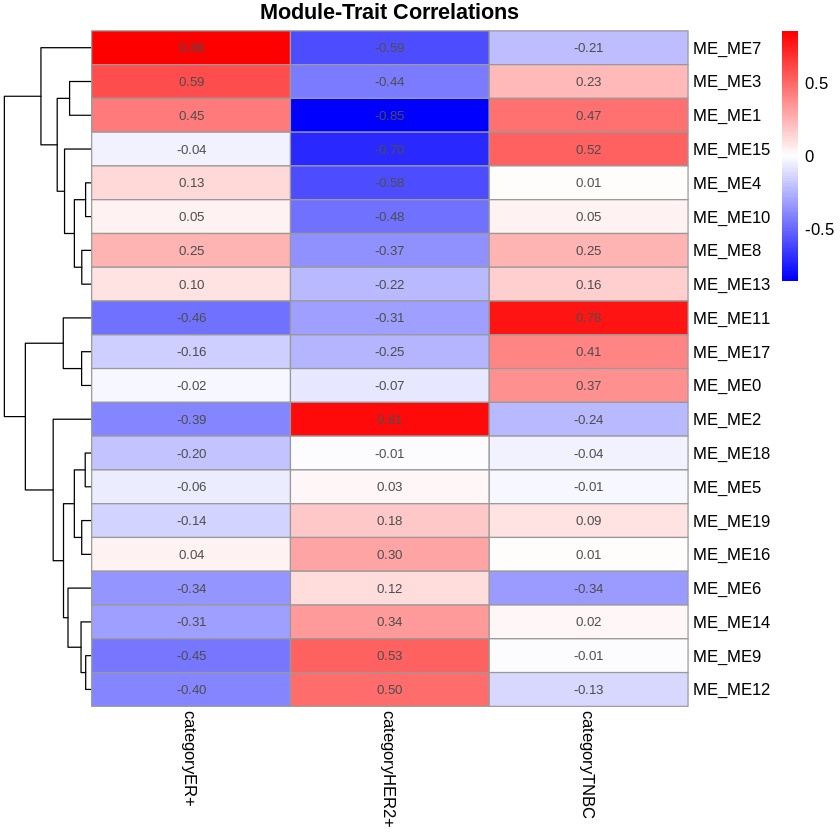

In [ ]:
# Ensure Metadata and Module Eigengenes Are Aligned
stopifnot(rownames(metadata) == rownames(MEs))  # Ensure samples match

# Convert Subtypes to Dummy Variables
trait_matrix <- model.matrix(~ category, data = metadata)[, -1]  # Dummy variables for subtypes
rownames(trait_matrix) <- rownames(metadata)  # Align sample IDs

# Output the Dummy Matrix for Review
cat("Trait Matrix (Dummy Variables):\n")
print(head(trait_matrix))



# Compute Correlations Between MEs and Traits
module_trait_cor <- cor(MEs, trait_matrix, use = "pairwise.complete.obs")

# Compute P-Values for Correlations
module_trait_pval <- corPvalueStudent(module_trait_cor, nrow(metadata))

# Save Results as Matrices
write.csv(module_trait_cor, "module_trait_correlations.csv")
write.csv(module_trait_pval, "module_trait_pvalues.csv")

# Combine Correlations and P-Values into a DataFrame for Easy Interpretation
moduleTraitResults <- data.frame(
  Module = rownames(module_trait_cor),
  TNBC_Correlation = module_trait_cor[, "categoryTNBC"],
  TNBC_P.value = module_trait_pval[, "categoryTNBC"],
  HER2_Correlation = module_trait_cor[, "categoryHER2+"],
  HER2_P.value = module_trait_pval[, "categoryHER2+"],
  ER_Correlation = module_trait_cor[, "categoryER+"],
  ER_P.value = module_trait_pval[, "categoryER+"]
)

# Save Combined Results
write.csv(moduleTraitResults, "module_trait_summary.csv")
cat("Module-Trait Results Saved as 'module_trait_summary.csv'\n")



# Prepare Data for Heatmap
install.packages('pheatmap')
library(pheatmap)

# Focus on Correlation Data
corHeatmapData <- module_trait_cor
rownames(corHeatmapData) <- paste("ME", rownames(corHeatmapData), sep = "_")
colnames(corHeatmapData) <- colnames(module_trait_cor)
# colnames(corHeatmapData) <- c("TNBC", "HER2+", "ER+")

# High-Resolution Heatmap
png("module_trait_heatmap.png", width = 3600, height = 2400, res = 300)
pheatmap(
  corHeatmapData,
  cluster_rows = TRUE,
  cluster_cols = FALSE,
  display_numbers = TRUE,
  number_format = "%.2f",
  main = "Module-Trait Correlations",
  color = colorRampPalette(c("blue", "white", "red"))(100)
)
dev.off()

cat("Heatmap saved as 'module_trait_heatmap.png'.\n")

In [ ]:
head(MEs)
head(moduleLabels)
head(geneModuleAssignments)
head(label_color_mapping)
head(moduleTraitResults)

,ME8,ME3,ME7,ME18,ME6,ME4,ME10,ME11,ME15,ME1,ME13,ME9,ME12,ME19,ME2,ME14,ME17,ME5,ME16,ME0
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GSM1401790,-0.012784355,-0.07339462,0.03932000,0.09027279,0.16014821,0.1853948,0.17466916,0.010953765,0.10405185,0.04644860,0.002704305,-0.07610230,-0.05342645,-0.060225261,-0.12779103,-0.040961856,0.0128505259,0.019398058,-0.12571922,-0.09533481
GSM1401791,0.005453018,-0.03860149,0.03213224,0.05788602,0.13716284,0.1647613,0.14050653,0.030139207,0.10935990,0.05378040,0.004702504,-0.06667332,-0.01787378,-0.056075585,-0.10663510,-0.043612303,0.0001011258,0.007931371,-0.08650917,-0.05221519
GSM1401792,0.004716480,-0.04702628,0.05698190,0.07884448,0.14017545,0.1715812,0.14841221,0.009525324,0.11455055,0.05570520,0.007772290,-0.07404784,-0.02396160,-0.038798548,-0.11003585,-0.033791459,-0.0020275684,0.003507304,-0.11601284,-0.06525550
GSM1401793,0.011400295,-0.06745076,0.02879769,0.08459915,0.18303986,0.2074110,0.18498232,0.014276858,0.09499439,0.06430526,0.032042679,-0.10768271,-0.09150291,-0.083773664,-0.12276784,-0.008880136,0.0109212740,0.002563509,-0.11990488,-0.08739119
GSM1401794,0.010838080,-0.02820886,0.03060134,0.04788129,0.11805769,0.1583088,0.14078431,0.039126753,0.09635718,0.05674873,0.008912830,-0.07879256,-0.10896137,-0.053802617,-0.10775807,-0.023679485,0.0073617239,0.012848204,-0.07103650,-0.05380714
GSM1401795,0.006598072,-0.04449133,0.03248688,0.05032804,0.09523088,0.1257433,0.07312668,0.029606796,0.11488230,0.05652245,0.008817277,-0.06115335,0.03816099,-0.008908728,-0.08454193,-0.035974246,-0.0294910339,0.001194341,-0.11028633,-0.03037733


DDX11L1    WASH7P MIR6859-1 MIR1302-2   FAM138A     OR4F5 
        3         3         3         5         1         1

,Gene,Module
,<chr>,<chr>
1,DDX11L1,brown
2,WASH7P,brown
3,MIR6859-1,brown
4,MIR1302-2,green
5,FAM138A,turquoise
6,OR4F5,turquoise


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'head': object 'label_color_mapping' not found


In [ ]:
# Define thresholds for module selection
cor_threshold <- 0.5  # Minimum correlation strength (can be adjusted)
pval_threshold <- 0.05  # Significance level

# Identify significantly correlated modules for each subtype
significant_modules_TNBC <- moduleTraitResults$Module[
  abs(moduleTraitResults$TNBC_Correlation) > cor_threshold &
  moduleTraitResults$TNBC_P.value < pval_threshold
]

significant_modules_HER2 <- moduleTraitResults$Module[
  abs(moduleTraitResults$HER2_Correlation) > cor_threshold &
  moduleTraitResults$HER2_P.value < pval_threshold
]

significant_modules_ER <- moduleTraitResults$Module[
  abs(moduleTraitResults$ER_Correlation) > cor_threshold &
  moduleTraitResults$ER_P.value < pval_threshold
]

In [ ]:
significant_modules_TNBC
significant_modules_HER2
significant_modules_ER

[1] "ME11" "ME15"

[1] "ME7"  "ME4"  "ME15" "ME1"  "ME9"  "ME2"

[1] "ME3" "ME7"

In [ ]:
convert_me_to_color <- function(modules, mapping_df) {
  mapped_colors <- mapping_df$ModuleColor[match(modules, mapping_df$ModuleLabel)]
  return(mapped_colors)
}

significant_modules_TNBC_colors <- convert_me_to_color(significant_modules_TNBC, mapping_df)
significant_modules_HER2_colors <- convert_me_to_color(significant_modules_HER2, mapping_df)
significant_modules_ER_colors   <- convert_me_to_color(significant_modules_ER,   mapping_df)

# Remove the turquoise module if it is present
significant_modules_TNBC_colors <- significant_modules_TNBC_colors[significant_modules_TNBC_colors != "turquoise"]
significant_modules_HER2_colors <- significant_modules_HER2_colors[significant_modules_HER2_colors != "turquoise"]
significant_modules_ER_colors   <- significant_modules_ER_colors[significant_modules_ER_colors != "turquoise"]


cat("TNBC Modules in Colors:\n", significant_modules_TNBC_colors, "\n")
cat("HER2+ Modules in Colors:\n", significant_modules_HER2_colors, "\n")
cat("ER+ Modules in Colors:\n", significant_modules_ER_colors, "\n")

TNBC Modules in Colors:
 greenyellow midnightblue 
HER2+ Modules in Colors:
 black yellow midnightblue magenta blue 
ER+ Modules in Colors:
 brown black 


In [ ]:
# --- Step 3: Extract genes using the converted colors ---
extract_genes <- function(modules, gene_data) {
  modules <- as.character(modules)
  gene_data$Module <- as.character(gene_data$Module)
  return(gene_data$Gene[gene_data$Module %in% modules])
}

TNBC_genes <- extract_genes(significant_modules_TNBC_colors, geneModuleAssignments)
HER2_genes <- extract_genes(significant_modules_HER2_colors, geneModuleAssignments)
ER_genes   <- extract_genes(significant_modules_ER_colors, geneModuleAssignments)

cat("TNBC genes extracted:", length(TNBC_genes), "\n")
cat("HER2+ genes extracted:", length(HER2_genes), "\n")
cat("ER+ genes extracted:", length(ER_genes), "\n")

TNBC genes extracted: 321 
HER2+ genes extracted: 9074 
ER+ genes extracted: 3781 


In [ ]:
module_counts <- table(geneModuleAssignments$Module)
print(module_counts)



       black         blue        brown         cyan        green  greenyellow 
         470         6198         3311          100         1013          234 
        grey       grey60    lightcyan   lightgreen  lightyellow      magenta 
        2876           49           53           38           33          400 
midnightblue         pink       purple          red       salmon          tan 
          87          452          323          535          140          173 
   turquoise       yellow 
        7346         1919 


In [ ]:
nGenes <- ncol(data)   # after your final data transpose, data has samples x genes
stopifnot(nGenes == ncol(TOM) && nGenes == nrow(TOM))


In [ ]:
# Example: For TNBC
TNBC_nodes <- geneModuleAssignments[geneModuleAssignments$Gene %in% TNBC_genes, ]
# This includes columns "Gene" and "Module"

# Optionally, add more columns: e.g., kME, annotation, etc.
# For example:
#   TNBC_nodes$kME <- ...
#   TNBC_nodes$Description <- ...
# Save to CSV
write.csv(TNBC_nodes, "TNBC_nodes.csv", row.names = FALSE)

# Repeat for HER2+ and ER+:
HER2_nodes <- geneModuleAssignments[geneModuleAssignments$Gene %in% HER2_genes, ]
write.csv(HER2_nodes, "HER2_nodes.csv", row.names = FALSE)

ER_nodes <- geneModuleAssignments[geneModuleAssignments$Gene %in% ER_genes, ]
write.csv(ER_nodes, "ER_nodes.csv", row.names = FALSE)

head(TNBC_nodes)
head(HER2_nodes)
head(ER_nodes)

,Gene,Module
,<chr>,<chr>
175,SLC2A5,greenyellow
342,IFFO2,midnightblue
367,UBXN10,greenyellow
495,LOC101928391,greenyellow
708,RIMS3,midnightblue
800,HPDL,greenyellow


,Gene,Module
,<chr>,<chr>
16,MIR12136,blue
22,LOC100288069,blue
23,LINC01409,blue
24,LINC00115,blue
25,LINC01128,yellow
26,LOC284600,blue


,Gene,Module
,<chr>,<chr>
1,DDX11L1,brown
2,WASH7P,brown
3,MIR6859-1,brown
8,LOC729737,brown
9,DDX11L17,brown
10,LOC102723897,brown


In [ ]:
###############################################################################
# 1) Compute adjacency (if not available)
###############################################################################
# Make sure 'data' is samples x genes. If your 'data' is genes x samples, do 't(data)'
softPower <- 6
adjacencyMat <- adjacency(
  data,        # samples x genes
  power = softPower,
  type  = "signed"
)


###############################################################################
# 2) Compute kME (module membership)
###############################################################################
# We already have MEs from your blockwiseModules. MEs is also samples x #modules.
# signedKME() expects 'datExpr' with rows = samples, columns = genes,
# exactly what we have if 'data' is samples x genes.
library(WGCNA)
kMEtable <- signedKME(
  data,     # samples x genes
  MEs,
  outputColumnName = "kME"
)
# This results in columns: kMEblack, kMEblue, kMEbrown, etc., for each module color.


###############################################################################
# 3) Compute intramodular connectivity (IMC)
###############################################################################
IMC <- intramodularConnectivity(
  adjMat = adjacencyMat,  # Must be genes x genes, see note below
  colors = moduleColors      # The same color vector from WGCNA
)

# Note: For adjacencyMat to be genes x genes, we might need to transpose 'data'
#   if our adjacency() call used 'rows = samples, columns = genes'.
#   The WGCNA function adjacency() usually returns a genes x genes matrix
#   if columns = genes. You can confirm with: dim(adjacencyMat).


###############################################################################
# 4) Build a Master Node Data Frame
###############################################################################
# Let’s assume:
#   - colnames(data) is the vector of gene names in the same order as adjacencyMat,
#   - geneModuleAssignments is a data frame with "Gene" and "Module".

allGenes <- colnames(data)  # vector of gene names
# Or if you have it as rownames of adjacencyMat, you can do: allGenes <- rownames(adjacencyMat)

# Build a data frame of gene info
masterNodes <- data.frame(
  Gene          = allGenes,
  Module        = moduleColors,               # same order as 'allGenes'
  kME_value     = NA,                         # placeholder
  kWithin       = IMC$kWithin,                # intramodular connectivity
  stringsAsFactors = FALSE
)

# Fill in each gene's actual kME for its assigned module
# e.g. if gene i is in "brown" module, then we grab kMEtable[i, "kMEbrown"]
for(i in seq_along(allGenes)) {
  geneColor <- moduleColors[i]
  # The columns of kMEtable are named kMEblack, kMEbrown, etc.
  kMEcolName <- paste0("kME", geneColor)
  masterNodes$kME_value[i] <- kMEtable[i, kMEcolName]
}


###############################################################################
# 5) Merge (Optional) Additional Columns
###############################################################################
# If you have per-gene correlations to the traits (TNBC vs. Normal, etc.),
# you could add them if you have them in a vector or data frame.
# For example, suppose you computed "geneCorr_TNBC" somehow.
# We'll skip that for brevity, but you can do:
# masterNodes$TNBC_corr <- geneCorr_TNBC
# ... and so on.


###############################################################################
# 6) Subset for Each Subtype and Write CSV
###############################################################################
# We assume you already have:
# TNBC_genes, HER2_genes, ER_genes
# These are vectors of gene names deemed significant for each subtype.

TNBC_nodes <- masterNodes[ masterNodes$Gene %in% TNBC_genes, ]
HER2_nodes <- masterNodes[ masterNodes$Gene %in% HER2_genes, ]
ER_nodes   <- masterNodes[ masterNodes$Gene %in% ER_genes, ]

write.csv(TNBC_nodes, "TNBC_nodes.csv", row.names = FALSE)
write.csv(HER2_nodes, "HER2_nodes.csv", row.names = FALSE)
write.csv(ER_nodes,   "ER_nodes.csv",   row.names = FALSE)

# That’s it! Now you have 3 node CSV files, each containing:
#   Gene, Module, kME_value, kWithin
# And you can add or remove columns as desired.


ERROR: Error in adjacency(data, power = softPower, type = "signed"): could not find function "adjacency"


In [ ]:
head(data)

                                                                            
1 function (..., list = character(), package = NULL, lib.loc = NULL,        
2     verbose = getOption("verbose"), envir = .GlobalEnv, overwrite = TRUE) 
3 {                                                                         
4     fileExt <- function(x) {                                              
5         db <- grepl("\\\\.[^.]+\\\\.(gz|bz2|xz)$", x)                     
6         ans <- sub(".*\\\\.", "", x)                                      

In [ ]:
system("apt-get update")
system("apt-get install -y libmagick++-dev")
system("apt-get install -y libhdf5-dev")

if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")
BiocManager::install("GSVA", version = "3.20", force = TRUE)
# Load required libraries
library(GSVA)
library(BiocParallel)  # Optional for parallel processing

# Install msigdbr
install.packages("msigdbr")

# Load msigdbr
library(msigdbr)

# fetch Hallmark pathways and Convert to a list format for GSVA
msigdb <- msigdbr(species = "Homo sapiens", category = "H")  # "H" is for Hallmark
gene_sets <- split(msigdb$gene_symbol, msigdb$gs_name)

# fetch Kegg pathways and Convert to a list format for GSVA
kegg <- msigdbr(species = "Homo sapiens", category = "C2", subcategory = "CP:KEGG")
kegg_gene_sets <- split(kegg$gene_symbol, kegg$gs_name)

# fetch Reactome pathways and Convert to a list format for GSVA
# reactome <- msigdbr(species = "Homo sapiens", category = "C2", subcategory = "CP:REACTOME")
# reactome_gene_sets <- split(reactome$gene_symbol, reactome$gs_name)

# fetch GO_bp pathways and Convert to a list format for GSVA
# go_bp <- msigdbr(species = "Homo sapiens", category = "C5", subcategory = "GO:BP")
# go_bp_gene_sets <- split(go_bp$gene_symbol, go_bp$gs_name)


all_gene_sets <- list(
    "Hallmark" = gene_sets,          # Your Hallmark pathways
    "KEGG" = kegg_gene_sets         # KEGG pathways
)
    # "Reactome" = reactome_gene_sets, # Reactome pathways
    # "GO_BP" = go_bp_gene_sets        # GO Biological Processes
# )

print(names(all_gene_sets))  # Should list "Hallmark", "KEGG", "Reactome", "GO_BP"


# View example pathways
# print(names(gene_sets))  # Pathway names
# print(gene_sets[1])      # Genes in the first pathway

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31)

Installing package(s) 'GSVA'

Old packages: 'data.table', 'processx'

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Hallmark" "KEGG"    


In [ ]:
# Load metadata (e.g., batch and category info)
metadata <- read.csv("/content/metadata.csv", row.names = 1, header = TRUE)

# Load raw gene expression count matrix
data <- read.csv("/content/updated_count_matrix (1).csv", row.names = 1, header = TRUE)

# Verify that column names in the count matrix match sample IDs in metadata
stopifnot(all(colnames(data) %in% rownames(metadata)))  # Stops if mismatch

# Retain genes expressed >15 counts in at least 25% of samples
data <- data[rowSums(data > 15) > round(0.25 * ncol(data)), ]
cat("Number of genes retained after filtering:", nrow(data), "\n")

# Load DESeq2
BiocManager::install("DESeq2")
BiocManager::install("limma")
library(DESeq2)
library(limma)

# Create DESeq2 object
dds <- DESeqDataSetFromMatrix(countData = data, colData = metadata, design = ~ batch + category)

# Perform normalization and variance stabilization
dds <- DESeq(dds)
vsd <- vst(dds, blind = FALSE)  # Variance-Stabilizing Transformation

# Extract variance-stabilized counts
vsd_counts <- assay(vsd)

# Design matrix to preserve the "category" effect while removing batch effects
design_matrix <- model.matrix(~ category, data = metadata)

# Remove batch effects
batch_corrected_data <- removeBatchEffect(vsd_counts, batch = metadata$batch, design = design_matrix)

class(batch_corrected_data)
# Output: "matrix"

Number of genes retained after filtering: 25750 


'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31)

Installing package(s) 'DESeq2'

also installing the dependencies ‘locfit’, ‘RcppArmadillo’


Old packages: 'data.table', 'processx'

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31)

Installing package(s) 'limma'

also installing the dependency ‘statmod’


Old packages: 'data.table', 'processx'

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var

[1] "matrix" "array"

In [ ]:
# Load necessary libraries
library(GSVA)
library(BiocParallel)

# Hallmark pathways
hallmark_param <- gsvaParam(
    expr = batch_corrected_data,
    geneSets = all_gene_sets$Hallmark
)
gsva_hallmark <- gsva(
    param = hallmark_param,
    verbose = TRUE,
    BPPARAM = MulticoreParam(workers = 4)
)

# KEGG pathways
kegg_param <- gsvaParam(
    expr = batch_corrected_data,
    geneSets = all_gene_sets$KEGG
)
gsva_kegg <- gsva(
    param = kegg_param,
    verbose = TRUE,
    BPPARAM = MulticoreParam(workers = 4)
)

# # Reactome pathways
# reactome_param <- gsvaParam(
#     expr = batch_corrected_data,
#     geneSets = all_gene_sets$Reactome
# )
# gsva_reactome <- gsva(
#     param = reactome_param,
#     verbose = TRUE,
#     BPPARAM = MulticoreParam(workers = 4)
# )

# # GO Biological Processes
# go_bp_param <- gsvaParam(
#     expr = batch_corrected_data,
#     geneSets = all_gene_sets$GO_BP
# )
# gsva_go_bp <- gsva(
#     param = go_bp_param,
#     verbose = TRUE,
#     BPPARAM = MulticoreParam(workers = 4)
# )

ℹ GSVA version 2.0.5

ℹ Using a MulticoreParam parallel back-end with 4 workers

ℹ Calculating GSVA ranks

ℹ kcdf='auto' (default)

ℹ GSVA dense (classical) algorithm

ℹ Direct row-wise ECDFs estimation

Estimating row ECDFs with 4 cores ■■■■■■■■■■■■■■■■                  50% | ETA: …

Estimating row ECDFs with 4 cores ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■  100% | ETA: …

ℹ Calculating GSVA column ranks

! Duplicated gene IDs removed from gene set HALLMARK_ADIPOGENESIS

! Duplicated gene IDs removed from gene set HALLMARK_ALLOGRAFT_REJECTION

! Duplicated gene IDs removed from gene set HALLMARK_ANDROGEN_RESPONSE

! Duplicated gene IDs removed from gene set HALLMARK_APICAL_JUNCTION

! Duplicated gene IDs removed from gene set HALLMARK_APICAL_SURFACE

! Duplicated gene IDs removed from gene set HALLMARK_APOPTOSIS

! Duplicated gene IDs removed from gene set HALLMARK_BILE_ACID_METABOLISM

! Duplicated gene IDs removed from gene set HALLMARK_CHOLESTEROL_HOMEOSTASIS

! Duplicated gene IDs removed 

In [ ]:
head(gsva_hallmark)
head(gsva_kegg)
# Save enrichment score matrices
write.csv(gsva_hallmark, "gsva_hallmark_results.csv", row.names = TRUE)
write.csv(gsva_kegg, "gsva_kegg_results.csv", row.names = TRUE)
# write.csv(gsva_reactome, "gsva_reactome_results.csv", row.names = TRUE)
# write.csv(gsva_go_bp, "gsva_go_bp_results.csv", row.names = TRUE)


,GSM1401790,GSM1401791,GSM1401792,GSM1401793,GSM1401794,GSM1401795,GSM1401796,GSM1401797,GSM1401798,GSM1401799,⋯,GSM7784748,GSM7784749,GSM7784750,GSM7784752,GSM7784753,GSM7784754,GSM7784755,GSM7784756,GSM7784757,GSM7784758
HALLMARK_ADIPOGENESIS,0.41982919,0.4183521,0.3407357,0.5917774,0.36415999,0.2903767,0.31157432,0.3150838,0.42013643,0.60573185,⋯,-0.1213928,0.17284972,-0.20550793,-0.33210542,0.169424030,0.18038564,-0.03390970,0.03833471,0.01621099,-0.14173091
HALLMARK_ALLOGRAFT_REJECTION,-0.02658332,-0.1643456,-0.1455419,-0.1925554,-0.08305033,-0.3311708,-0.02283354,-0.3057555,-0.05048430,0.08640916,⋯,0.1086215,0.10200422,0.12113549,-0.22473071,-0.059751726,0.06730002,-0.01136667,0.14316233,0.24951811,0.08574988
HALLMARK_ANDROGEN_RESPONSE,0.32638012,0.2737046,0.2475654,0.2811204,0.12959534,0.2598956,0.32603475,0.1390074,-0.09952142,0.16608283,⋯,-0.1454530,0.31675820,-0.35610751,-0.39776734,-0.049506455,0.23330645,-0.03004703,-0.27263433,-0.20742579,-0.19185929
HALLMARK_ANGIOGENESIS,0.54931614,0.4513081,0.5567791,0.5161870,0.55727877,0.1414177,0.37205862,0.4813327,0.49443159,0.39873873,⋯,-0.3639691,0.38028923,-0.28862118,-0.50097124,-0.426352378,-0.30293801,-0.43412767,-0.43200582,-0.47929239,-0.51769853
HALLMARK_APICAL_JUNCTION,0.41477355,0.3908822,0.3998031,0.2896233,0.40733898,0.2308865,0.35897928,0.4201456,0.36133838,0.28363887,⋯,-0.3751731,0.16147706,-0.29114083,-0.32459605,-0.283605125,-0.29659108,-0.25563636,-0.26734680,-0.29930369,-0.40533167
HALLMARK_APICAL_SURFACE,0.36615711,0.2273846,0.3335199,0.1826144,0.29767963,0.2485199,0.31073511,0.1936501,0.19512998,0.15755246,⋯,-0.3711736,0.07602036,-0.08449618,-0.09501672,-0.006080103,0.02879122,-0.18580690,-0.09627350,-0.10014422,-0.30606220


,GSM1401790,GSM1401791,GSM1401792,GSM1401793,GSM1401794,GSM1401795,GSM1401796,GSM1401797,GSM1401798,GSM1401799,⋯,GSM7784748,GSM7784749,GSM7784750,GSM7784752,GSM7784753,GSM7784754,GSM7784755,GSM7784756,GSM7784757,GSM7784758
KEGG_ABC_TRANSPORTERS,0.18051598,0.26324640,0.22775496,0.29492993,0.24327901,0.01318887,-0.05831415,0.15733839,0.38196988,0.2748318,⋯,0.15652961,-0.0455893883,0.39649300,0.08388809,0.12480759,0.31826250,0.09025510,0.02872903,0.39785078,0.27299846
KEGG_ACUTE_MYELOID_LEUKEMIA,0.40108779,0.18179180,0.23304572,0.16048068,0.12721531,0.04920571,0.18356522,0.02281452,0.05468537,0.3465722,⋯,-0.25635740,0.1488434757,-0.28096813,-0.29074251,0.29096307,0.30702754,0.03751505,0.05595992,-0.18557583,-0.39165566
KEGG_ADHERENS_JUNCTION,0.35002466,0.26831201,0.22479113,0.04658727,0.22311425,0.18822373,0.31349056,0.17684198,0.02661996,0.1955676,⋯,-0.02151593,0.4794506312,-0.31220429,-0.51318379,-0.27812241,-0.15726757,-0.37353839,-0.37439765,-0.19432408,-0.22008899
KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY,0.44577730,0.31215342,0.41994575,0.39123044,0.45662277,0.32164351,0.35644100,0.27913527,0.36578919,0.4364261,⋯,-0.33988963,-0.0152802519,-0.25467614,-0.26870750,-0.16918170,-0.23829867,-0.16315960,-0.05914476,-0.11636487,-0.22166922
KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISM,0.03617767,0.05606518,-0.04867731,0.03821783,0.08912264,0.15501395,0.11352964,-0.01826295,-0.14388780,0.1811572,⋯,0.01413107,-0.1262194559,0.21756674,-0.06774452,-0.06041445,-0.08279089,-0.10614438,-0.18000588,0.26766637,0.01396276
KEGG_ALDOSTERONE_REGULATED_SODIUM_REABSORPTION,0.48430859,0.39753190,0.39712583,0.32470112,0.34681601,0.35810046,0.46337869,0.36285045,0.30989355,0.3172168,⋯,0.04908144,0.0006120067,-0.06220618,-0.12941907,0.15014558,0.02113892,0.17791020,0.04160485,-0.08422148,-0.16947224


In [ ]:
# Replace "+" with an empty string to remove it from category names
metadata$category <- gsub("\\+", "", metadata$category)
# Verify the unique category names
print(unique(metadata$category))

# Sets Normal as the baseline (first level)
metadata$category <- factor(metadata$category, levels = c("Normal", "HER2", "ER", "TNBC"))


# Build the design matrix
design <- model.matrix(~ 0 + category, data = metadata)
colnames(design) <- c("Normal", "HER2", "ER", "TNBC") # Ensure column names match the group names in "category"


# Create contrasts (each subtype vs Normal)
contrast_matrix <- makeContrasts(
  HER2_vs_Normal = HER2 - Normal,
  ER_vs_Normal   = ER   - Normal,
  TNBC_vs_Normal = TNBC - Normal,
  levels = design
)

[1] "Normal" "ER"     "TNBC"   "HER2"  


In [ ]:
# ----------------------------
# (2) Differential analysis for Hallmark
# ----------------------------
fit_hallmark <- lmFit(gsva_hallmark, design)
fit_hallmark <- contrasts.fit(fit_hallmark, contrast_matrix)
fit_hallmark <- eBayes(fit_hallmark)

# Extract results for each contrast
hallmark_res_HER2  <- topTable(fit_hallmark, coef = "HER2_vs_Normal", number = Inf, adjust.method = "BH")
hallmark_res_ER    <- topTable(fit_hallmark, coef = "ER_vs_Normal",   number = Inf, adjust.method = "BH")
hallmark_res_TNBC  <- topTable(fit_hallmark, coef = "TNBC_vs_Normal", number = Inf, adjust.method = "BH")

# ----------------------------
# (3) Differential analysis for KEGG
# ----------------------------
fit_kegg <- lmFit(gsva_kegg, design)
fit_kegg <- contrasts.fit(fit_kegg, contrast_matrix)
fit_kegg <- eBayes(fit_kegg)

# Extract results for each contrast
kegg_res_HER2  <- topTable(fit_kegg, coef = "HER2_vs_Normal",  number = Inf, adjust.method = "BH")
kegg_res_ER    <- topTable(fit_kegg, coef = "ER_vs_Normal",    number = Inf, adjust.method = "BH")
kegg_res_TNBC  <- topTable(fit_kegg, coef = "TNBC_vs_Normal",  number = Inf, adjust.method = "BH")

head(hallmark_res_HER2)
head(kegg_res_HER2)



,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HALLMARK_COAGULATION,-0.5958932,-0.062961988,-15.85756,4.580655e-41,2.290327e-39,82.54101
HALLMARK_MYOGENESIS,-0.6709161,-0.060148026,-15.29802,5.208069e-39,1.302017e-37,77.82596
HALLMARK_E2F_TARGETS,0.7983338,0.050875841,14.67347,1.006854e-36,1.678090e-35,72.58325
HALLMARK_G2M_CHECKPOINT,0.7458570,0.033863177,14.40737,9.407712e-36,1.175964e-34,70.35816
HALLMARK_BILE_ACID_METABOLISM,-0.4159398,-0.032532929,-14.26308,3.152216e-35,3.152216e-34,69.15431
HALLMARK_PANCREAS_BETA_CELLS,-0.5342345,-0.004545667,-13.61907,6.781618e-33,5.651349e-32,63.80771


,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
KEGG_HOMOLOGOUS_RECOMBINATION,0.8138116,0.05463548,21.21583,1.177988e-60,2.191058e-58,127.49125
KEGG_HYPERTROPHIC_CARDIOMYOPATHY_HCM,-0.6447044,-0.06498879,-18.77124,8.721132e-52,8.110653e-50,107.18120
KEGG_DILATED_CARDIOMYOPATHY,-0.6450844,-0.06898886,-18.48897,9.443369e-51,5.854889e-49,104.81185
KEGG_LONG_TERM_DEPRESSION,-0.5012251,-0.05723578,-18.40021,1.998760e-50,9.294235e-49,104.06607
KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY,-0.5523623,-0.05717485,-16.76220,2.127832e-44,7.915535e-43,90.26245
KEGG_PPAR_SIGNALING_PATHWAY,-0.5174953,-0.03939861,-16.52684,1.567272e-43,4.858542e-42,88.27645


In [ ]:
library(dplyr)
# For each table, rename columns to differentiate them
hallmark_res_HER2  <- hallmark_res_HER2  %>% rename(adj.P.Val_HER2 = adj.P.Val,  logFC_HER2 = logFC)
hallmark_res_ER    <- hallmark_res_ER    %>% rename(adj.P.Val_ER   = adj.P.Val,  logFC_ER   = logFC)
hallmark_res_TNBC  <- hallmark_res_TNBC  %>% rename(adj.P.Val_TNBC = adj.P.Val, logFC_TNBC = logFC)

# Combines the three results tables into a unified table with all comparisons.
# Merge by row name (pathway name) because rownames() typically store the pathway names in GSVA results
hallmark_combined <- hallmark_res_HER2 %>%
  select(logFC_HER2, adj.P.Val_HER2) %>%
  merge(hallmark_res_ER %>% select(logFC_ER, adj.P.Val_ER),
        by = "row.names", all = TRUE) %>%
  merge(hallmark_res_TNBC %>% select(logFC_TNBC, adj.P.Val_TNBC),
        by.x = "Row.names", by.y = "row.names", all = TRUE)

# Rename the first column (Row.names) to "Pathway" for clarity
colnames(hallmark_combined)[1] <- "Pathway"
rownames(hallmark_combined) <- hallmark_combined$Pathway
hallmark_combined$Pathway <- NULL
head(hallmark_combined)

# Compute average activity score for HALLMARK pathways
avg_activity <- rowMeans(gsva_hallmark, na.rm = TRUE)
# Add the activity score to the combined table
# Ensure the row names of gsva_hallmark (pathway names) match the row names in your combined table
hallmark_combined$ActivityScore <- avg_activity[rownames(hallmark_combined)]
head(hallmark_combined)

# Assuming your combined table is named 'hallmark_combined' and its row names are pathway names.
sig_threshold <- 0.05
# For example, you may decide that a pathway is significant if it meets the threshold in at least one contrast.
significant_pathways <- hallmark_combined[
  (hallmark_combined$adj.P.Val_HER2 < sig_threshold) |
  (hallmark_combined$adj.P.Val_ER < sig_threshold) |
  (hallmark_combined$adj.P.Val_TNBC < sig_threshold),
]
# Check the number of significant pathways
cat("Number of significant pathways:", nrow(significant_pathways), "\n")


library(dplyr)

# Rename columns for each contrast in the KEGG results
kegg_res_HER2  <- kegg_res_HER2  %>% rename(adj.P.Val_HER2 = adj.P.Val,  logFC_HER2 = logFC)
kegg_res_ER    <- kegg_res_ER    %>% rename(adj.P.Val_ER   = adj.P.Val,  logFC_ER   = logFC)
kegg_res_TNBC  <- kegg_res_TNBC  %>% rename(adj.P.Val_TNBC = adj.P.Val, logFC_TNBC = logFC)

# Combine the three results tables into a unified table for KEGG using the pathway names (rownames)
kegg_combined <- kegg_res_HER2 %>%
  select(logFC_HER2, adj.P.Val_HER2) %>%
  merge(kegg_res_ER %>% select(logFC_ER, adj.P.Val_ER),
        by = "row.names", all = TRUE) %>%
  merge(kegg_res_TNBC %>% select(logFC_TNBC, adj.P.Val_TNBC),
        by.x = "Row.names", by.y = "row.names", all = TRUE)

# Rename the first column ("Row.names") to "Pathway" and set it as rownames
colnames(kegg_combined)[1] <- "Pathway"
rownames(kegg_combined) <- kegg_combined$Pathway
kegg_combined$Pathway <- NULL

# Inspect the combined table
head(kegg_combined)

# Compute average activity score for KEGG pathways
avg_activity_kegg <- rowMeans(gsva_kegg, na.rm = TRUE)

# Add the activity score to the combined KEGG table
# Make sure that the row names of gsva_kegg (i.e., pathway names) match those in kegg_combined
kegg_combined$ActivityScore <- avg_activity_kegg[rownames(kegg_combined)]
head(kegg_combined)

# Define the significance threshold
sig_threshold <- 0.05

# Filter for significant KEGG pathways (significant in at least one contrast)
significant_pathways_kegg <- kegg_combined[
  (kegg_combined$adj.P.Val_HER2 < sig_threshold) |
  (kegg_combined$adj.P.Val_ER < sig_threshold) |
  (kegg_combined$adj.P.Val_TNBC < sig_threshold),
]

# Check the number of significant pathways
cat("Number of significant KEGG pathways:", nrow(significant_pathways_kegg), "\n")

,logFC_HER2,adj.P.Val_HER2,logFC_ER,adj.P.Val_ER,logFC_TNBC,adj.P.Val_TNBC
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HALLMARK_ADIPOGENESIS,-0.3750432,5.706969e-14,-0.4983084,1.432161e-16,-0.57696367,1.016203e-21
HALLMARK_ALLOGRAFT_REJECTION,0.1115504,1.759108e-02,-0.2983605,1.214153e-07,0.07350019,1.784848e-01
HALLMARK_ANDROGEN_RESPONSE,-0.2109260,1.142938e-04,-0.4527714,1.343726e-11,-0.45310550,4.498929e-12
HALLMARK_ANGIOGENESIS,-0.6377230,3.360451e-24,-0.4259925,1.440192e-09,-0.38495980,1.567467e-08
HALLMARK_APICAL_JUNCTION,-0.5025284,2.072973e-23,-0.3235093,1.070823e-08,-0.37014972,3.186054e-11
HALLMARK_APICAL_SURFACE,-0.3068199,5.706969e-14,-0.3192654,3.365238e-11,-0.35689003,5.937332e-14


,logFC_HER2,adj.P.Val_HER2,logFC_ER,adj.P.Val_ER,logFC_TNBC,adj.P.Val_TNBC,ActivityScore
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HALLMARK_ADIPOGENESIS,-0.3750432,5.706969e-14,-0.4983084,1.432161e-16,-0.57696367,1.016203e-21,-0.02508176
HALLMARK_ALLOGRAFT_REJECTION,0.1115504,1.759108e-02,-0.2983605,1.214153e-07,0.07350019,1.784848e-01,0.01626589
HALLMARK_ANDROGEN_RESPONSE,-0.2109260,1.142938e-04,-0.4527714,1.343726e-11,-0.45310550,4.498929e-12,-0.02607397
HALLMARK_ANGIOGENESIS,-0.6377230,3.360451e-24,-0.4259925,1.440192e-09,-0.38495980,1.567467e-08,-0.06123896
HALLMARK_APICAL_JUNCTION,-0.5025284,2.072973e-23,-0.3235093,1.070823e-08,-0.37014972,3.186054e-11,-0.05085880
HALLMARK_APICAL_SURFACE,-0.3068199,5.706969e-14,-0.3192654,3.365238e-11,-0.35689003,5.937332e-14,-0.02874227


Number of significant pathways: 47 


,logFC_HER2,adj.P.Val_HER2,logFC_ER,adj.P.Val_ER,logFC_TNBC,adj.P.Val_TNBC
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
KEGG_ABC_TRANSPORTERS,-0.08105773,5.126779e-02,-0.11002540,2.629164e-02,-0.4157173,1.899251e-16
KEGG_ACUTE_MYELOID_LEUKEMIA,-0.18001758,3.028432e-04,-0.36308780,1.980766e-09,-0.4116750,4.709565e-12
KEGG_ADHERENS_JUNCTION,-0.20948061,2.175465e-04,-0.46666749,1.854334e-11,-0.3878657,6.016432e-09
KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY,-0.55236229,7.915535e-43,-0.33266208,4.747209e-15,-0.4748410,3.424820e-27
KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISM,-0.08870488,1.241367e-02,-0.03869744,3.775415e-01,-0.1667411,5.145132e-05
KEGG_ALDOSTERONE_REGULATED_SODIUM_REABSORPTION,-0.40663096,1.739746e-27,-0.50353377,1.739136e-28,-0.4742807,3.424820e-27


,logFC_HER2,adj.P.Val_HER2,logFC_ER,adj.P.Val_ER,logFC_TNBC,adj.P.Val_TNBC,ActivityScore
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
KEGG_ABC_TRANSPORTERS,-0.08105773,5.126779e-02,-0.11002540,2.629164e-02,-0.4157173,1.899251e-16,0.01643437
KEGG_ACUTE_MYELOID_LEUKEMIA,-0.18001758,3.028432e-04,-0.36308780,1.980766e-09,-0.4116750,4.709565e-12,-0.02419719
KEGG_ADHERENS_JUNCTION,-0.20948061,2.175465e-04,-0.46666749,1.854334e-11,-0.3878657,6.016432e-09,-0.04774243
KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY,-0.55236229,7.915535e-43,-0.33266208,4.747209e-15,-0.4748410,3.424820e-27,-0.05717485
KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISM,-0.08870488,1.241367e-02,-0.03869744,3.775415e-01,-0.1667411,5.145132e-05,-0.01809291
KEGG_ALDOSTERONE_REGULATED_SODIUM_REABSORPTION,-0.40663096,1.739746e-27,-0.50353377,1.739136e-28,-0.4742807,3.424820e-27,-0.02101879


Number of significant KEGG pathways: 184 


In [ ]:
# Create a node data frame for Hallmark pathways
pathway_nodes_hallmark <- data.frame(
  Pathway = rownames(significant_pathways),   # 'significant_pathways' comes from the filtered combined table for Hallmark
  ActivityScore = significant_pathways$ActivityScore,
  AdjPValue_HER2 = significant_pathways$adj.P.Val_HER2,
  AdjPValue_ER   = significant_pathways$adj.P.Val_ER,
  AdjPValue_TNBC = significant_pathways$adj.P.Val_TNBC,
  NodeType = "Pathway",  # Labeling the node type
  stringsAsFactors = FALSE
)
# Inspect the first few rows of the Hallmark node data
head(pathway_nodes_hallmark)
write.csv(pathway_nodes_hallmark, "pathway_nodes_hallmark.csv", row.names = FALSE)
cat("Pathway node data saved as 'pathway_nodes_hallmark.csv'.\n")

# Create a node data frame for KEGG pathways
pathway_nodes_kegg <- data.frame(
  Pathway = rownames(significant_pathways_kegg),  # From the filtered KEGG table
  ActivityScore = significant_pathways_kegg$ActivityScore,
  AdjPValue_HER2 = significant_pathways_kegg$adj.P.Val_HER2,
  AdjPValue_ER   = significant_pathways_kegg$adj.P.Val_ER,
  AdjPValue_TNBC = significant_pathways_kegg$adj.P.Val_TNBC,
  NodeType = "Pathway",
  stringsAsFactors = FALSE
)

# Inspect the first few rows of the KEGG node data
head(pathway_nodes_kegg)
write.csv(pathway_nodes_kegg, "pathway_nodes_kegg.csv", row.names = FALSE)
cat("Pathway node data saved as 'pathway_nodes_kegg.csv'.\n")



,Pathway,ActivityScore,AdjPValue_HER2,AdjPValue_ER,AdjPValue_TNBC,NodeType
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,HALLMARK_ADIPOGENESIS,-0.02508176,5.706969e-14,1.432161e-16,1.016203e-21,Pathway
2,HALLMARK_ALLOGRAFT_REJECTION,0.01626589,1.759108e-02,1.214153e-07,1.784848e-01,Pathway
3,HALLMARK_ANDROGEN_RESPONSE,-0.02607397,1.142938e-04,1.343726e-11,4.498929e-12,Pathway
4,HALLMARK_ANGIOGENESIS,-0.06123896,3.360451e-24,1.440192e-09,1.567467e-08,Pathway
5,HALLMARK_APICAL_JUNCTION,-0.05085880,2.072973e-23,1.070823e-08,3.186054e-11,Pathway
6,HALLMARK_APICAL_SURFACE,-0.02874227,5.706969e-14,3.365238e-11,5.937332e-14,Pathway


Pathway node data saved as 'pathway_nodes_hallmark.csv'.


,Pathway,ActivityScore,AdjPValue_HER2,AdjPValue_ER,AdjPValue_TNBC,NodeType
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,KEGG_ABC_TRANSPORTERS,0.01643437,5.126779e-02,2.629164e-02,1.899251e-16,Pathway
2,KEGG_ACUTE_MYELOID_LEUKEMIA,-0.02419719,3.028432e-04,1.980766e-09,4.709565e-12,Pathway
3,KEGG_ADHERENS_JUNCTION,-0.04774243,2.175465e-04,1.854334e-11,6.016432e-09,Pathway
4,KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY,-0.05717485,7.915535e-43,4.747209e-15,3.424820e-27,Pathway
5,KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISM,-0.01809291,1.241367e-02,3.775415e-01,5.145132e-05,Pathway
6,KEGG_ALDOSTERONE_REGULATED_SODIUM_REABSORPTION,-0.02101879,1.739746e-27,1.739136e-28,3.424820e-27,Pathway


Pathway node data saved as 'pathway_nodes_kegg.csv'.


In [ ]:
# Combine your significant gene lists if desired
# (Alternatively, you can process each separately.)
significant_genes_all <- unique(c(TNBC_genes, HER2_genes, ER_genes))

# Convert the significant gene list to uppercase
significant_genes_all <- toupper(significant_genes_all)

# Convert all gene sets in your GSVA collections to uppercase.
# For Hallmark:
all_gene_sets$Hallmark <- lapply(all_gene_sets$Hallmark, toupper)
# For KEGG:
all_gene_sets$KEGG <- lapply(all_gene_sets$KEGG, toupper)


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'unique': object 'TNBC_genes' not found


In [ ]:
# Initialize an empty data frame for Hallmark edges
edge_list_hallmark <- data.frame(Gene = character(), Pathway = character(), stringsAsFactors = FALSE)

# Loop over each pathway in the Hallmark gene sets
for (pathway in names(all_gene_sets$Hallmark)) {

  # Get the genes defined in this pathway
  genes_in_pathway <- all_gene_sets$Hallmark[[pathway]]

  # Find the intersection with your significant genes
  valid_genes <- intersect(genes_in_pathway, significant_genes_all)

  # If there are any genes in common, create edges
  if (length(valid_genes) > 0) {
    edges_temp <- data.frame(
      Gene = valid_genes,
      Pathway = rep(pathway, length(valid_genes)),
      stringsAsFactors = FALSE
    )
    edge_list_hallmark <- rbind(edge_list_hallmark, edges_temp)
  }
}

# View the first few edges for Hallmark
head(edge_list_hallmark)


ERROR: Error: object 'significant_genes_all' not found


In [ ]:
# Initialize an empty data frame for KEGG edges
edge_list_kegg <- data.frame(Gene = character(), Pathway = character(), stringsAsFactors = FALSE)

# Loop over each pathway in the KEGG gene sets
for (pathway in names(all_gene_sets$KEGG)) {

  # Get the genes defined in this KEGG pathway
  genes_in_pathway <- all_gene_sets$KEGG[[pathway]]

  # Intersect with your significant gene list
  valid_genes <- intersect(genes_in_pathway, significant_genes_all)

  # Create edges if there is an overlap
  if (length(valid_genes) > 0) {
    edges_temp <- data.frame(
      Gene = valid_genes,
      Pathway = rep(pathway, length(valid_genes)),
      stringsAsFactors = FALSE
    )
    edge_list_kegg <- rbind(edge_list_kegg, edges_temp)
  }
}

# View the first few edges for KEGG
head(edge_list_kegg)


,Gene,Pathway
,<chr>,<chr>
1,ABCA12,KEGG_ABC_TRANSPORTERS
2,ABCA2,KEGG_ABC_TRANSPORTERS
3,ABCA3,KEGG_ABC_TRANSPORTERS
4,ABCA5,KEGG_ABC_TRANSPORTERS
5,ABCA7,KEGG_ABC_TRANSPORTERS
6,ABCB5,KEGG_ABC_TRANSPORTERS


In [ ]:
# Combine the two edge lists (if desired)
edge_list_combined <- rbind(edge_list_hallmark, edge_list_kegg)

# Inspect the combined edge list
head(edge_list_combined)

# Save the edge list to a CSV file for downstream network analysis
write.csv(edge_list_combined, "gene_pathway_edges.csv", row.names = FALSE)
cat("Gene–Pathway edge data saved as 'gene_pathway_edges.csv'.\n")


,Gene,Pathway
,<chr>,<chr>
1,ABCB8,HALLMARK_ADIPOGENESIS
2,ACAA2,HALLMARK_ADIPOGENESIS
3,ACADL,HALLMARK_ADIPOGENESIS
4,ACADM,HALLMARK_ADIPOGENESIS
5,ACADS,HALLMARK_ADIPOGENESIS
6,ACOX1,HALLMARK_ADIPOGENESIS


Gene–Pathway edge data saved as 'gene_pathway_edges.csv'.


In [ ]:
edge_list_combined <- read.csv("/content/gene_pathway_edges.csv", header = TRUE)
gene_nodes <- read.csv("/content/nodes.csv", header = TRUE)

In [ ]:
# Remove the first column (assuming it is "X")
gene_nodes <- gene_nodes[, -1]

# View the updated data frame
head(gene_nodes)


,Gene,Module,kME,TNBC_Correlation,HER2_Correlation,ER_Correlation
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,DDX11L1,brown,0.1853948,0.2502656,-0.3666227,0.2482694
2,WASH7P,brown,0.1647613,0.2502656,-0.3666227,0.2482694
3,MIR6859-1,brown,0.1715812,0.2502656,-0.3666227,0.2482694
4,FAM138A,turquoise,0.1583088,0.2502656,-0.3666227,0.2482694
5,OR4F5,turquoise,0.1257433,0.2502656,-0.3666227,0.2482694
6,WASH9P,grey,0.1198575,0.2502656,-0.3666227,0.2482694


In [ ]:
# Extract the unique gene names from the edge list
unique_genes <- unique(edge_list_combined$Gene)

# (Optional) Standardize case if needed—for example, converting to uppercase:
unique_genes <- toupper(unique_genes)
gene_nodes$Gene <- toupper(gene_nodes$Gene)

# Filter the gene_nodes so only those genes present in the edge list remain
filtered_gene_nodes <- gene_nodes[gene_nodes$Gene %in% unique_genes, ]

# Check the numbers before and after filtering
cat("Number of genes before filtering:", nrow(gene_nodes), "\n")
cat("Number of genes after filtering:", nrow(filtered_gene_nodes), "\n")

# Optionally, save the filtered node file
write.csv(filtered_gene_nodes, "filtered_gene_nodes.csv", row.names = FALSE)
cat("Filtered gene nodes saved as 'filtered_gene_nodes.csv'.\n")


Number of genes before filtering: 24737 
Number of genes after filtering: 3712 
Filtered gene nodes saved as 'filtered_gene_nodes.csv'.


In [ ]:
# Load required packages (if not already loaded)
library(dplyr)

# -------------------------------------------------------------------
# Step 1: Load the pathway node attribute files for Hallmark and KEGG
# -------------------------------------------------------------------

# Load pathway node files (assumes they were saved as CSV files)
hallmark_nodes <- read.csv("pathway_nodes_hallmark.csv", stringsAsFactors = FALSE)
kegg_nodes     <- read.csv("pathway_nodes_kegg.csv", stringsAsFactors = FALSE)

# For consistency, rename the pathway identifier column to "ID" and add a "Type" column.
# (Assuming in your CSV, the pathway name is stored in a column called "Pathway".)
hallmark_nodes <- hallmark_nodes %>%
  rename(ID = Pathway) %>%
  mutate(Type = "Pathway")

kegg_nodes <- kegg_nodes %>%
  rename(ID = Pathway) %>%
  mutate(Type = "Pathway")

# Combine the two pathway node data frames into one master pathway node table.
pathway_nodes <- bind_rows(hallmark_nodes, kegg_nodes)

# -------------------------------------------------------------------
# Step 2: Load the gene node attribute file from WGCNA results
# -------------------------------------------------------------------

# Load the gene nodes (e.g., your 'nodes.csv' file)
gene_nodes <- read.csv("filtered_gene_nodes.csv", stringsAsFactors = FALSE)

# Rename the gene column to "ID" and add a "Type" column indicating these are gene nodes.
gene_nodes <- gene_nodes %>%
  rename(ID = Gene) %>%
  mutate(Type = "Gene")

# -------------------------------------------------------------------
# Step 3: Harmonize the columns between the two node types
# -------------------------------------------------------------------
# We want the master table to include the following columns:
# "ID", "Type", "ActivityScore", "AdjPValue_HER2", "AdjPValue_ER", "AdjPValue_TNBC",
# "kME", "TNBC_Correlation", "HER2_Correlation", "ER_Correlation", "Module"

# For pathway nodes, gene-level attributes (kME, correlations, Module) are not applicable.
# For gene nodes, pathway-level attributes (ActivityScore, Adjusted p-values) are not applicable.

# For pathway nodes, add the gene-related columns with NA values:
pathway_nodes$kME               <- NA
pathway_nodes$TNBC_Correlation  <- NA
pathway_nodes$HER2_Correlation  <- NA
pathway_nodes$ER_Correlation    <- NA
pathway_nodes$Module            <- NA

# For gene nodes, add the pathway-related columns with NA values:
gene_nodes$ActivityScore        <- NA
gene_nodes$AdjPValue_HER2       <- NA
gene_nodes$AdjPValue_ER         <- NA
gene_nodes$AdjPValue_TNBC       <- NA

# Optionally, rearrange columns so that both data frames have the same column order.
desired_cols <- c("ID", "Type", "ActivityScore", "AdjPValue_HER2",
                  "AdjPValue_ER", "AdjPValue_TNBC", "kME",
                  "TNBC_Correlation", "HER2_Correlation", "ER_Correlation", "Module")

# Make sure both data frames have these columns in the same order:
pathway_nodes <- pathway_nodes[, desired_cols]
gene_nodes    <- gene_nodes[, desired_cols]

# -------------------------------------------------------------------
# Step 4: Combine the gene and pathway nodes into one master node attribute table
# -------------------------------------------------------------------
master_node_attributes <- bind_rows(pathway_nodes, gene_nodes)

# Inspect the first few rows of the master table:
head(master_node_attributes)

# -------------------------------------------------------------------
# Step 5: Save the master node attribute table to a CSV file
# -------------------------------------------------------------------
write.csv(master_node_attributes, "master_node_attributes.csv", row.names = FALSE)
cat("Master node attribute table saved as 'master_node_attributes.csv'.\n")



Attaching package: ‘dplyr’


The following object is masked from ‘package:gridExtra’:

    combine


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:matrixStats’:

    count


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




,ID,Type,ActivityScore,AdjPValue_HER2,AdjPValue_ER,AdjPValue_TNBC,kME,TNBC_Correlation,HER2_Correlation,ER_Correlation,Module
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,HALLMARK_ADIPOGENESIS,Pathway,-0.02508176,5.706969e-14,1.432161e-16,1.016203e-21,NA,NA,NA,NA,NA
2,HALLMARK_ALLOGRAFT_REJECTION,Pathway,0.01626589,1.759108e-02,1.214153e-07,1.784848e-01,NA,NA,NA,NA,NA
3,HALLMARK_ANDROGEN_RESPONSE,Pathway,-0.02607397,1.142938e-04,1.343726e-11,4.498929e-12,NA,NA,NA,NA,NA
4,HALLMARK_ANGIOGENESIS,Pathway,-0.06123896,3.360451e-24,1.440192e-09,1.567467e-08,NA,NA,NA,NA,NA
5,HALLMARK_APICAL_JUNCTION,Pathway,-0.05085880,2.072973e-23,1.070823e-08,3.186054e-11,NA,NA,NA,NA,NA
6,HALLMARK_APICAL_SURFACE,Pathway,-0.02874227,5.706969e-14,3.365238e-11,5.937332e-14,NA,NA,NA,NA,NA


Master node attribute table saved as 'master_node_attributes.csv'.
